<a href="https://colab.research.google.com/github/gouthamisarasani05-tech/Dissertation/blob/main/Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank_personal_loan_data.csv")

# Display first 5 rows
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
# Check shape
print("Shape:", df.shape)

# Check column names
print("Columns:", df.columns)

# Check data types
print(df.info())

# Check missing values
print(df.isnull().sum())

Shape: (5000, 14)
Columns: Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account

Data Preprocessing

In [ ]:
# Drop unnecessary columns
df = df.drop(["ID", "ZIP Code"], axis=1)

# Rename target column for convenience
df = df.rename(columns={"Personal Loan": "Loan"})

df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [ ]:
X = df.drop("Loan", axis=1)
y = df["Loan"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Exploratory Data Analysis (EDA)

Loan
0    4520
1     480
Name: count, dtype: int64


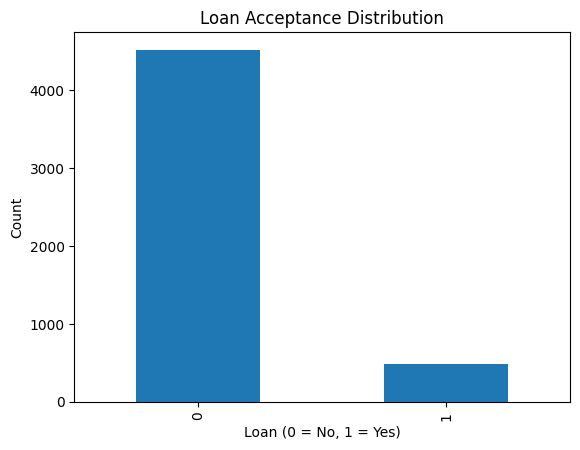

In [ ]:
import matplotlib.pyplot as plt

# Count values
print(df["Loan"].value_counts())

# Plot
df["Loan"].value_counts().plot(kind="bar")
plt.title("Loan Acceptance Distribution")
plt.xlabel("Loan (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

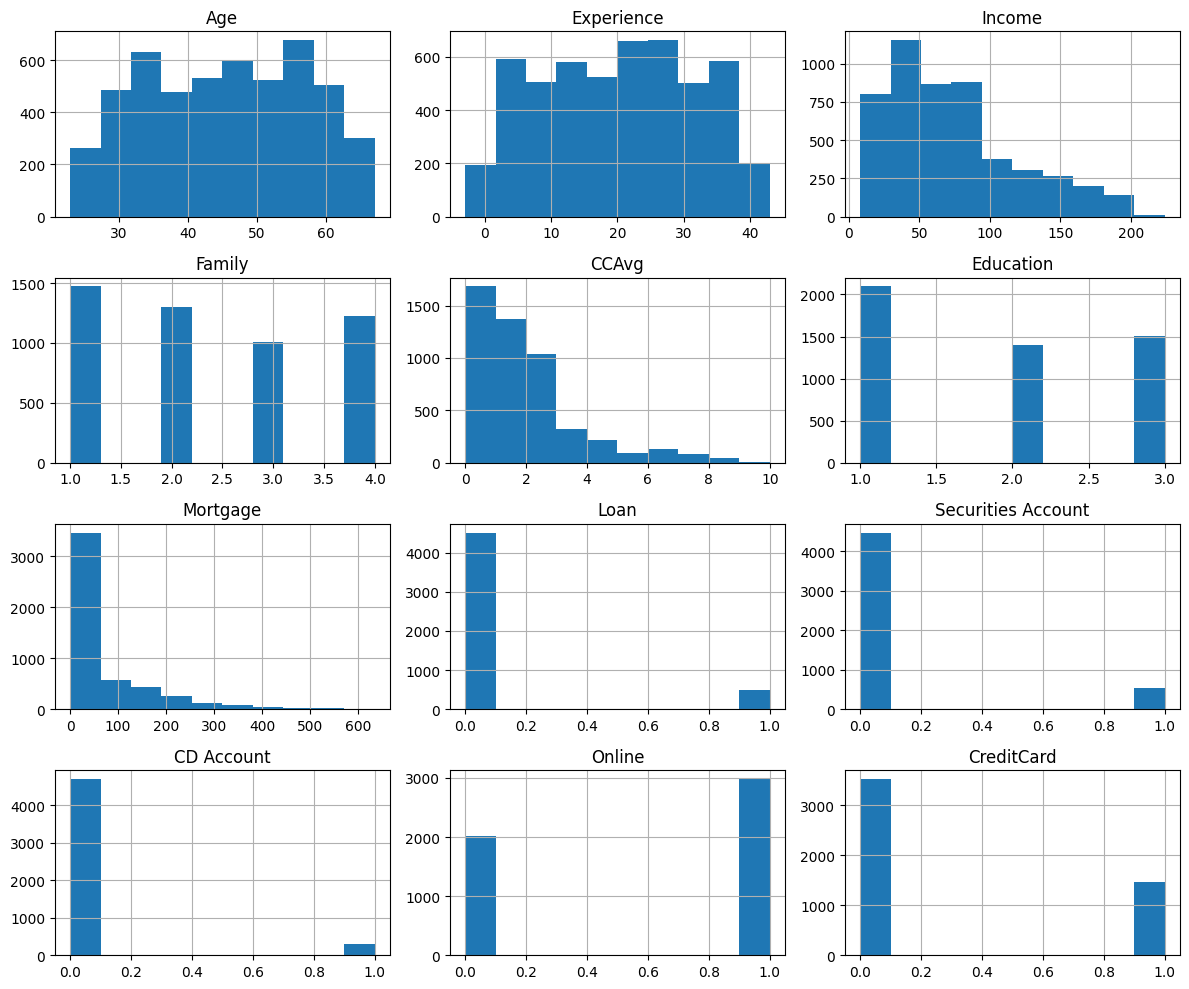

In [ ]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

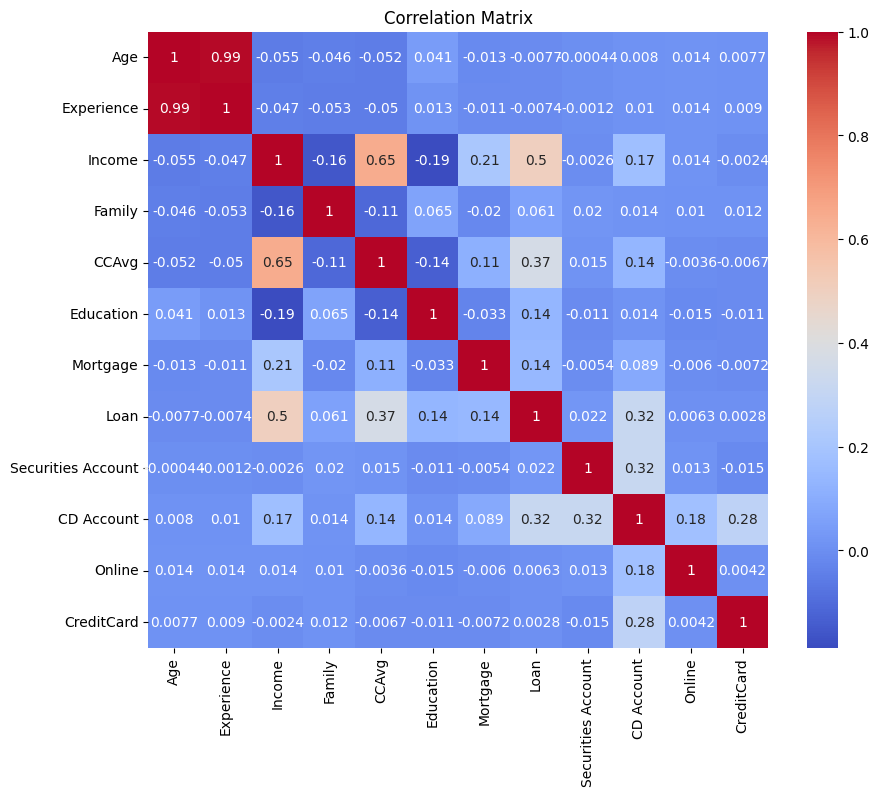

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

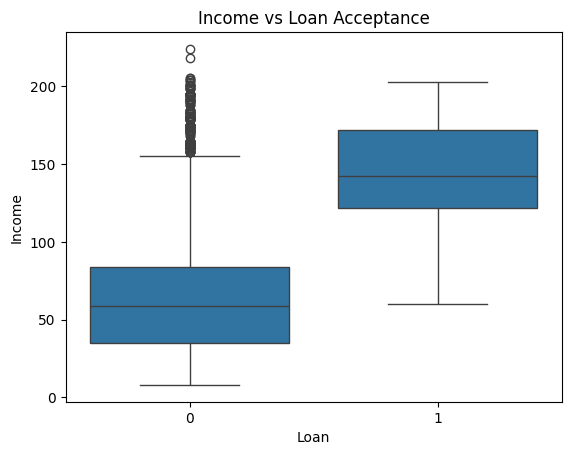

In [ ]:
sns.boxplot(x="Loan", y="Income", data=df)
plt.title("Income vs Loan Acceptance")
plt.show()

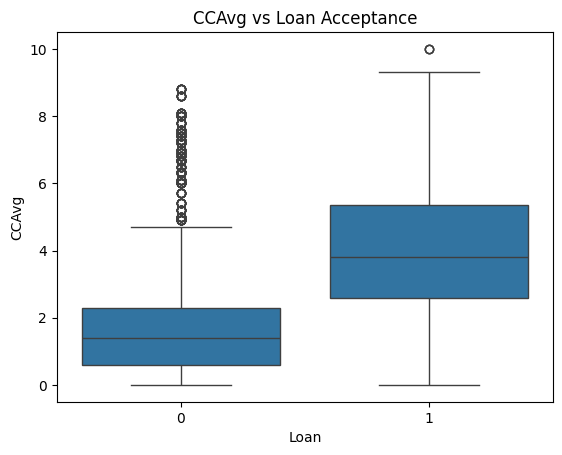

In [ ]:
sns.boxplot(x="Loan", y="CCAvg", data=df)
plt.title("CCAvg vs Loan Acceptance")
plt.show()

Model Development (Training Models)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# Logistic Regression
y_pred_lr = lr.predict(X_test_scaled)

# Decision Tree
y_pred_dt = dt.predict(X_test)

# Random Forest
y_pred_rf = rf.predict(X_test)

# Gradient Boosting
y_pred_gb = gb.predict(X_test_scaled)

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr),
    "Decision Tree": evaluate_model(y_test, y_pred_dt),
    "Random Forest": evaluate_model(y_test, y_pred_rf),
    "Gradient Boosting": evaluate_model(y_test, y_pred_gb)
}

results

{'Logistic Regression': {'Accuracy': 0.955,
  'Precision': 0.8571428571428571,
  'Recall': 0.6857142857142857,
  'F1 Score': 0.7619047619047619},
 'Decision Tree': {'Accuracy': 0.988,
  'Precision': 0.9514563106796117,
  'Recall': 0.9333333333333333,
  'F1 Score': 0.9423076923076923},
 'Random Forest': {'Accuracy': 0.991,
  'Precision': 0.9897959183673469,
  'Recall': 0.9238095238095239,
  'F1 Score': 0.9556650246305419},
 'Gradient Boosting': {'Accuracy': 0.992,
  'Precision': 0.98989898989899,
  'Recall': 0.9333333333333333,
  'F1 Score': 0.9607843137254902}}

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression     0.955   0.857143  0.685714  0.761905
Decision Tree           0.988   0.951456  0.933333  0.942308
Random Forest           0.991   0.989796  0.923810  0.955665
Gradient Boosting       0.992   0.989899  0.933333  0.960784


In [ ]:
# Need probabilities
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC LR:", roc_auc_score(y_test, y_prob_lr))
print("ROC-AUC RF:", roc_auc_score(y_test, y_prob_rf))
print("ROC-AUC GB:", roc_auc_score(y_test, y_prob_gb))

ROC-AUC LR: 0.9683320031923384
ROC-AUC RF: 0.9990955041234371
ROC-AUC GB: 0.998978451715882


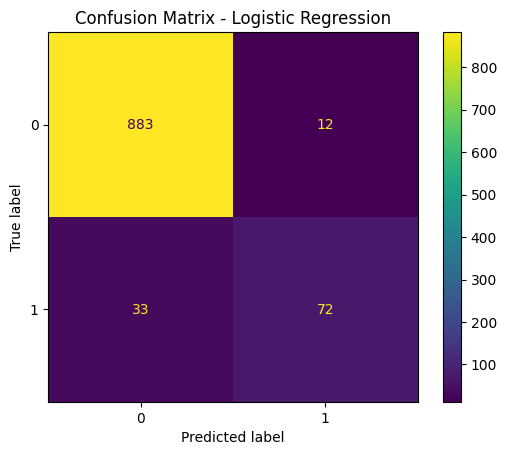

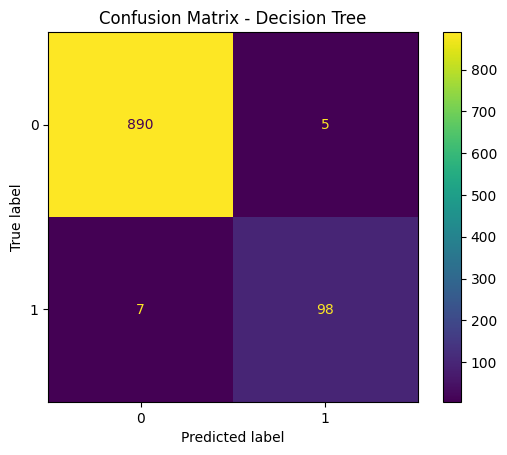

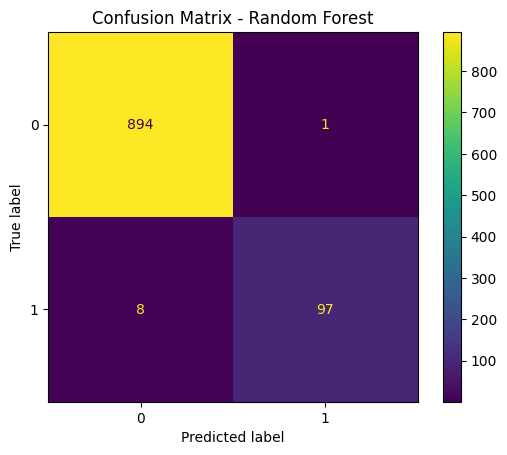

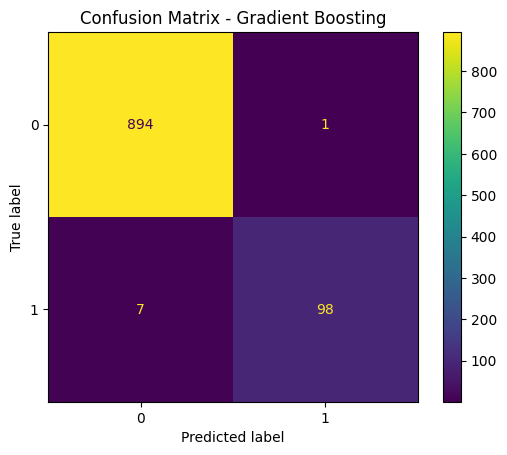

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": (y_test, y_pred_lr),
    "Decision Tree": (y_test, y_pred_dt),
    "Random Forest": (y_test, y_pred_rf),
    "Gradient Boosting": (y_test, y_pred_gb)
}

for name, (y_true, y_pred) in models.items():
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [ ]:
from sklearn.metrics import classification_report

for name, (y_true, y_pred) in models.items():
    print(f"\n{name}")
    print(classification_report(y_true, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.86      0.69      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.84      0.87      1000
weighted avg       0.95      0.95      0.95      1000


Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       895
           1       0.95      0.93      0.94       105

    accuracy                           0.99      1000
   macro avg       0.97      0.96      0.97      1000
weighted avg       0.99      0.99      0.99      1000


Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       895
           1       0.99      0.92      0.96       105

    accuracy                           0.99      1000
   macro avg       0.99      0.96      0.98      1000
weighted avg       0.99

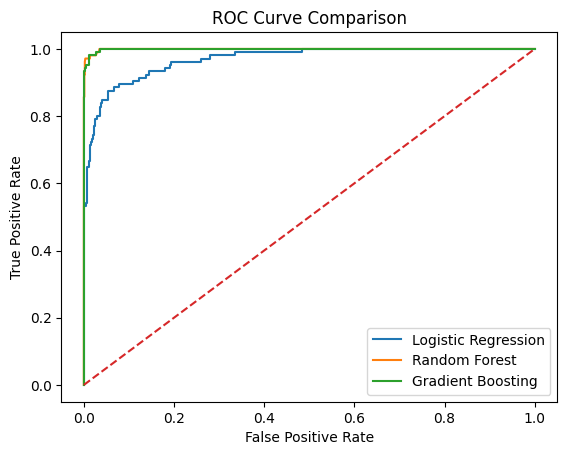

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure()

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

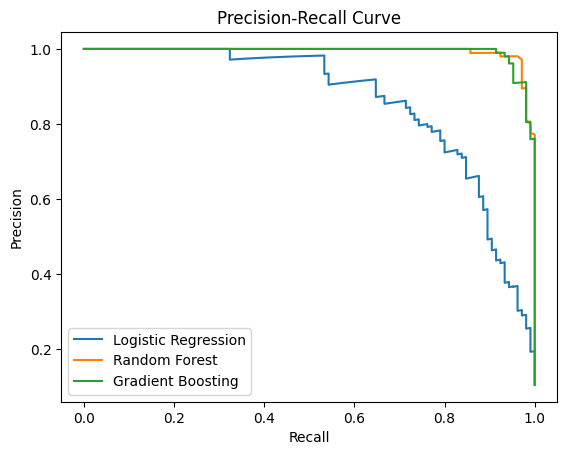

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

# LR
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label="Logistic Regression")

# RF
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label="Random Forest")

# GB
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_prob_gb)
plt.plot(recall_gb, precision_gb, label="Gradient Boosting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)

print("Best GB Params:", gb_grid.best_params_)

Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

# Predictions
y_pred_rf_best = best_rf.predict(X_test)
y_pred_gb_best = best_gb.predict(X_test_scaled)

In [ ]:
print("RF Tuned F1:", f1_score(y_test, y_pred_rf_best))
print("GB Tuned F1:", f1_score(y_test, y_pred_gb_best))

RF Tuned F1: 0.9458128078817734
GB Tuned F1: 0.9607843137254902


Explainable AI (SHAP + LIME)

In [ ]:
pip install shap

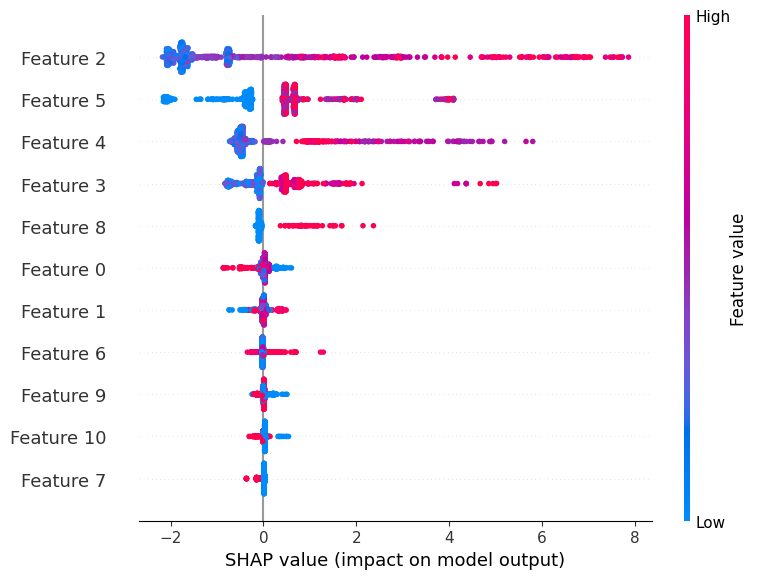

In [ ]:
import shap

# Use best model (Gradient Boosting is best in your case)
explainer = shap.Explainer(best_gb)

shap_values = explainer(X_test_scaled)

# Summary Plot (MOST IMPORTANT)
shap.summary_plot(shap_values, X_test_scaled)

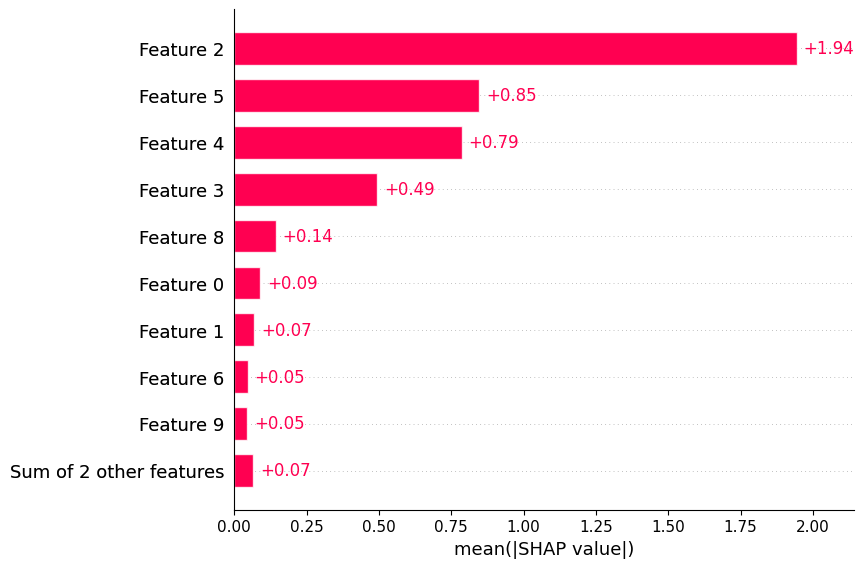

In [ ]:
shap.plots.bar(shap_values)

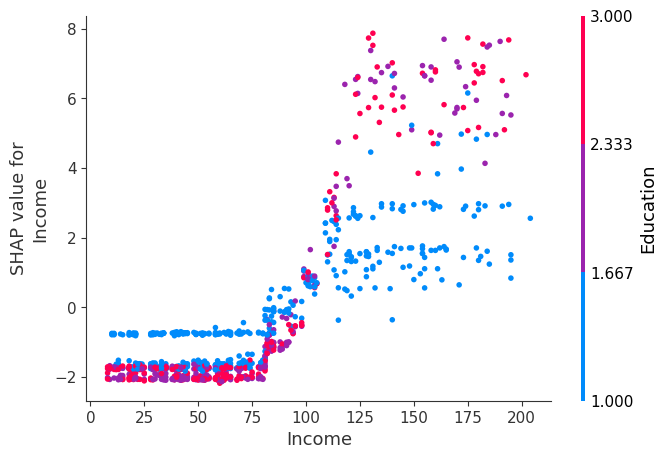

In [ ]:
shap.dependence_plot("Income", shap_values.values, X_test)

LIME (Local Explanation)

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f51a58a51ce8e89d33b2fb251cdf8b70539ca457967f7f6152f097f769e99cec
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
print(exp.as_list())

[('Income <= -0.76', -0.29949546186821), ('CD Account <= -0.25', -0.06385130846369468), ('CCAvg <= -0.70', -0.021475314047008063), ('-0.65 < CreditCard <= 1.55', -0.019904375785636544), ('-1.21 < Family <= -0.33', 0.015558915108631301), ('Age <= -0.90', 0.01119882659015086), ('Mortgage <= -0.55', -0.009210671134266513), ('-1.05 < Education <= 0.14', -0.00888858821767624), ('Online <= -1.22', -0.008671195955389243), ('Securities Account > -0.35', -0.004910500327069463)]


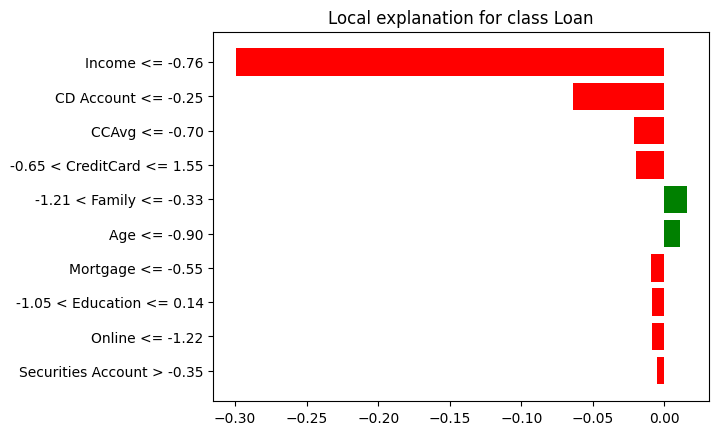

In [ ]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
plt.show()

In [ ]:
import lime
import lime.lime_tabular

In [ ]:
exp.show_in_notebook()